# Batched Deep CFR GPU Validation

This notebook checks the batched Deep CFR traversal backend before using it for long GPU runs.

In [1]:
from pathlib import Path
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'liars_poker').exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from liars_poker.algo.br_exact_dense_to_dense import best_response_dense
from liars_poker.algo.deep_cfr import DeepCFRTrainer
from liars_poker.algo.deep_cfr_diagnostics import ExactDenseStrategyAverager
from liars_poker.algo.neural_cfr_batched import BatchedDeepCFRTraverser
from liars_poker.core import GameSpec, card_rank, generate_deck
from liars_poker.env import resolve_call_winner, rules_for_spec
from liars_poker.infoset import CALL
from liars_poker.policies.neural import compile_neural_to_dense
from liars_poker.training.deep_cfr import deep_cfr_loop, deep_cfr_timed_loop

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch', torch.__version__)
print('device', device)
if torch.cuda.is_available():
    print('gpu', torch.cuda.get_device_name(0))

torch 2.12.0+cpu
device cpu


In [20]:
spec = GameSpec(
    ranks=4,
    suits=4,
    hand_size=4,
    claim_kinds=('RankHigh', 'Pair', 'Trips'),
    suit_symmetry=True,
)
rules = rules_for_spec(spec)
print(spec.to_short_str())
print('claims', len(rules.claims))

r4_s4_h4_hpt_ss
claims 12


## Static Correctness Checks

In [21]:
def hand_counts(hand, spec):
    counts = np.zeros(spec.ranks, dtype=np.float32)
    for card in hand:
        counts[card_rank(card, spec) - 1] += 1.0
    return counts

trainer = DeepCFRTrainer(
    spec,
    hidden_sizes=(16,),
    device=device,
    seed=11,
    traversal_backend='batched',
    traversal_batch_size=8,
)
runner = BatchedDeepCFRTraverser(trainer)

deck = list(generate_deck(spec))
rng = random.Random(123)
p1_hands = []
p2_hands = []
for _ in range(12):
    rng.shuffle(deck)
    p1_hands.append(tuple(sorted(deck[:spec.hand_size])))
    p2_hands.append(tuple(sorted(deck[spec.hand_size:2 * spec.hand_size])))

p1_counts = torch.as_tensor(np.stack([hand_counts(h, spec) for h in p1_hands]), device=device)
p2_counts = torch.as_tensor(np.stack([hand_counts(h, spec) for h in p2_hands]), device=device)
total_counts = p1_counts + p2_counts

claim_ids = [0, min(1, len(rules.claims) - 1), len(rules.claims) - 1]
hids = [1 << claim for claim in claim_ids for _ in range(4)]
deal_ids = list(range(len(hids)))

batched_values = runner._terminal_values(
    hids=hids,
    deal_indices=deal_ids,
    caller=1,
    traverser=0,
    total_counts=total_counts,
)
slow_values = []
for hid, deal_id in zip(hids, deal_ids):
    claim = hid.bit_length() - 1
    winner = resolve_call_winner(spec, (claim, CALL), p1_hands[deal_id], p2_hands[deal_id])
    slow_values.append(1.0 if winner == 'P1' else -1.0)

assert np.allclose(batched_values, np.asarray(slow_values, dtype=np.float32))
print('terminal resolution ok')

terminal resolution ok


In [22]:
history = (0, 2) if len(rules.claims) > 2 else (0,)
hid = sum(1 << action for action in history)
features = runner._features(
    actor=0,
    node_indices=[0],
    deal_indices=[0],
    hids=[hid],
    p1_counts=p1_counts[:1],
    p2_counts=p2_counts[:1],
).detach().cpu().numpy()[0]
expected = trainer.encoder.encode(p1_hands[0], history)
assert np.allclose(features, expected)
print('feature encoding ok')

feature encoding ok


## Smoke Training

In [23]:
def exact_exploitability(policy):
    dense = compile_neural_to_dense(policy)
    _, meta = best_response_dense(spec, dense, debug=False, store_state_values=False)
    p_first, p_second = meta['computer'].exploitability()
    return 0.5 * (p_first + p_second)

def short_run(backend, *, seed=5):
    trainer = DeepCFRTrainer(
        spec,
        hidden_sizes=(32, 32),
        device=device,
        seed=seed,
        batch_size=64,
        advantage_train_steps=5,
        strategy_train_steps=5,
        advantage_positive_weight=0.5,
        traversal_backend=backend,
        traversal_batch_size=32,
        validation_fraction=0.05,
    )
    policy, logs, trainer = deep_cfr_loop(
        spec,
        iterations=5,
        trainer=trainer,
        traversals_per_player=32,
        eval_every=5,
        debug=False,
    )
    return policy, logs, trainer

recursive_policy, recursive_logs, recursive_trainer = short_run('recursive', seed=5)
batched_policy, batched_logs, batched_trainer = short_run('batched', seed=5)

pd.DataFrame([
    {
        'backend': 'recursive',
        'advantage records': sum(recursive_logs['training_series'][-1]['advantage_records_seen']),
        'strategy records': sum(recursive_logs['training_series'][-1]['strategy_records_seen']),
        'final exploitability': recursive_logs['exploitability_series'][-1]['predicted_avg'],
    },
    {
        'backend': 'batched',
        'advantage records': sum(batched_logs['training_series'][-1]['advantage_records_seen']),
        'strategy records': sum(batched_logs['training_series'][-1]['strategy_records_seen']),
        'final exploitability': batched_logs['exploitability_series'][-1]['predicted_avg'],
    },
])

,backend,advantage records,strategy records,final exploitability
0,recursive,6386,10798,0.785940
1,batched,5378,11092,0.787518


## Backend Timing

In [28]:
def time_backend(backend, *, traversal_batch_size=128, traversals_per_player=1024, seed=19):
    trainer = DeepCFRTrainer(
        spec,
        hidden_sizes=(128, 128),
        device=device,
        seed=seed,
        batch_size=512,
        advantage_train_steps=20,
        strategy_train_steps=20,
        advantage_positive_weight=0.5,
        traversal_backend=backend,
        traversal_batch_size=traversal_batch_size,
    )
    record = trainer.run_iteration(traversals_per_player=traversals_per_player)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    timing = record['timing']
    return {
        'backend': backend,
        'traversal batch size': traversal_batch_size if backend == 'batched' else np.nan,
        'traversal s': timing['traversal_s'],
        'fit s': timing['advantage_training_s'] + timing['strategy_training_s'],
        'advantage records': sum(record['new_advantage_records']),
        'strategy records': sum(record['new_strategy_records']),
    }

timing_rows = [time_backend('recursive')]
for batch_size in ([32, 64, 128, 256, 512, 1024] if torch.cuda.is_available() else [16, 32, 64, 128, 256, 512, 1024]):
    timing_rows.append(time_backend('batched', traversal_batch_size=batch_size))

timing_df = pd.DataFrame(timing_rows)
timing_df['records / traversal s'] = (
    timing_df['advantage records'] + timing_df['strategy records']
) / timing_df['traversal s']
timing_df

,backend,traversal batch size,traversal s,fit s,advantage records,strategy records,records / traversal s
0,recursive,NaN,7.952575,0.398955,2355,26028,3569.032537
1,batched,16.0,1.092713,0.423655,2270,24500,24498.667307
2,batched,32.0,0.794492,0.416505,2422,26598,36526.461861
3,batched,64.0,0.587997,0.444574,2260,24586,45656.726587
4,batched,128.0,0.503423,0.399744,2484,26444,57462.610967
5,batched,256.0,2.651214,0.445607,2444,26841,11045.884798
6,batched,512.0,0.409863,0.440667,2515,27061,72160.785623
7,batched,1024.0,0.423596,0.410723,2401,25977,66993.046678


In [32]:
TIMING_TRAVERSALS_PER_PLAYER = 2048
TIMING_REPEATS = 5
TIMING_BATCH_SIZES = [32, 64, 128, 256, 512, 1024, 2048]
INCLUDE_RECURSIVE_BASELINE = True

rows = []
if INCLUDE_RECURSIVE_BASELINE:
    rows.append(time_backend(
        'recursive',
        traversals_per_player=TIMING_TRAVERSALS_PER_PLAYER,
        seed=99,
    ) | {'repeat': 0})

for b in TIMING_BATCH_SIZES:
    for repeat in range(TIMING_REPEATS):
        rows.append(time_backend(
            'batched',
            traversal_batch_size=b,
            traversals_per_player=TIMING_TRAVERSALS_PER_PLAYER,
            seed=100 + repeat,
        ) | {'repeat': repeat})

timing_repeat_df = pd.DataFrame(rows)
timing_repeat_df['total records'] = timing_repeat_df['advantage records'] + timing_repeat_df['strategy records']
timing_repeat_df['records / traversal s'] = timing_repeat_df['total records'] / timing_repeat_df['traversal s']

timing_summary_df = (
    timing_repeat_df
    .groupby(['backend', 'traversal batch size'], dropna=False)
    .agg(
        repeats=('traversal s', 'size'),
        median_traversal_s=('traversal s', 'median'),
        mean_traversal_s=('traversal s', 'mean'),
        std_traversal_s=('traversal s', 'std'),
        median_fit_s=('fit s', 'median'),
        median_records=('total records', 'median'),
        median_records_per_traversal_s=('records / traversal s', 'median'),
    )
    .reset_index()
    .sort_values(['backend', 'traversal batch size'], na_position='first')
)

display(timing_summary_df)
display(timing_repeat_df.sort_values(['backend', 'traversal batch size', 'repeat'], na_position='first').reset_index(drop=True))

,backend,traversal batch size,repeats,median_traversal_s,mean_traversal_s,std_traversal_s,median_fit_s,median_records,median_records_per_traversal_s
0,batched,32.0,5,1.378947,1.381196,0.064741,0.405994,52138.0,38025.559762
1,batched,64.0,5,1.103813,1.118833,0.056672,0.398115,54280.0,50953.558103
2,batched,128.0,5,0.959197,0.985979,0.093135,0.401412,54854.0,57370.881112
3,batched,256.0,5,0.802198,0.859308,0.091328,0.411308,52758.0,65749.475597
4,batched,512.0,5,0.871347,0.831857,0.077885,0.419053,52442.0,60742.182851
5,batched,1024.0,5,0.754372,0.818340,0.103183,0.448282,53411.0,67886.886121
6,batched,2048.0,5,0.861143,0.819543,0.099658,0.423389,53690.0,62347.354074
7,recursive,NaN,1,14.811429,14.811429,NaN,0.418103,51712.0,3491.358042


,backend,traversal batch size,traversal s,fit s,advantage records,strategy records,repeat,total records,records / traversal s
0,batched,32.0,1.389375,0.417308,4306,47444,0,51750,37246.958201
1,batched,32.0,1.319137,0.404351,4249,47118,1,51367,38939.843487
2,batched,32.0,1.484317,0.399588,4780,51662,2,56442,38025.559762
3,batched,32.0,1.378947,0.414472,4321,47817,3,52138,37810.010102
4,batched,32.0,1.334201,0.405994,4395,48150,4,52545,39383.112579
5,batched,64.0,1.168460,0.400877,4372,49102,0,53474,45764.498803
6,batched,64.0,1.068674,0.412708,4671,50770,1,55441,51878.333279
7,batched,64.0,1.187935,0.386596,4286,47459,2,51745,43558.795240
8,batched,64.0,1.103813,0.395701,4751,52005,3,56756,51418.115727
9,batched,64.0,1.065284,0.398115,4561,49719,4,54280,50953.558103


## Longer GPU Run

Set `RUN_GPU_TRAINING = True` after confirming the timing table. Exact evaluation is intentionally infrequent.

In [ ]:
RUN_GPU_TRAINING = True

if RUN_GPU_TRAINING:
    run_spec = GameSpec(
        ranks=4,
        suits=4,
        hand_size=3,
        claim_kinds=('RankHigh', 'Pair', 'Trips'),
        suit_symmetry=True,
    )
    exact_averager = ExactDenseStrategyAverager(run_spec)
    trainer = DeepCFRTrainer(
        run_spec,
        hidden_sizes=(256, 256),
        device=device,
        seed=7,
        batch_size=1024 if torch.cuda.is_available() else 1024,
        advantage_train_steps=100,
        strategy_train_steps=50,
        advantage_positive_weight=0.5,
        advantage_buffer_capacity=300_000,
        strategy_buffer_capacity=300_000,
        traversal_backend='batched',
        traversal_batch_size=1024 if torch.cuda.is_available() else 1024,
        validation_fraction=0.02,
        validation_buffer_capacity=20_000,
    )
    policy, logs, trainer = deep_cfr_timed_loop(
        run_spec,
        training_seconds=60*60,
        trainer=trainer,
        traversals_per_player=512,
        eval_every=10,
        exact_averager=exact_averager,
        debug=True,
    )
else:
    logs = {'training_series': [], 'exploitability_series': []}
    trainer = None
    policy = None

[deep-cfr] iter=1 training_budget=3.96/3600.00s traverse=1.63s fit=2.33s
[deep-cfr] iter=2 training_budget=7.71/3600.00s traverse=1.87s fit=1.88s
[deep-cfr] iter=3 training_budget=10.92/3600.00s traverse=1.33s fit=1.88s
[deep-cfr] iter=4 training_budget=13.96/3600.00s traverse=1.15s fit=1.89s
[deep-cfr] iter=5 training_budget=17.17/3600.00s traverse=1.21s fit=2.00s
[deep-cfr] iter=6 training_budget=20.59/3600.00s traverse=1.52s fit=1.90s
[deep-cfr] iter=7 training_budget=23.71/3600.00s traverse=1.21s fit=1.91s
[deep-cfr] iter=8 training_budget=27.13/3600.00s traverse=1.46s fit=1.97s
[deep-cfr] iter=9 training_budget=30.35/3600.00s traverse=1.22s fit=1.99s
[deep-cfr] iter=10 training_budget=33.81/3600.00s traverse=1.53s fit=1.94s
[deep-cfr] iter=11 training_budget=37.08/3600.00s traverse=1.25s fit=2.02s
[deep-cfr] iter=12 training_budget=40.19/3600.00s traverse=1.24s fit=1.87s
[deep-cfr] iter=13 training_budget=43.61/3600.00s traverse=1.52s fit=1.90s
[deep-cfr] iter=14 training_budget=4

,iteration,advantage_loss,strategy_loss,advantage_buffer_sizes,strategy_buffer_sizes,advantage_records_seen,strategy_records_seen,new_advantage_records,new_strategy_records,elapsed_s,timing.traversal_s,timing.advantage_training_s,timing.strategy_training_s,validation.advantage,validation.strategy
1224,1225,"[0.6131792461872101, 0.6287288582324981]","[0.4230664050579071, 0.3878002578020096]","[300000, 300000]","[300000, 300000]","[11791423, 3479575]","[11717476, 38896521]","[10734, 2515]","[8356, 33112]",3590.458208,1.236331,1.128871,0.538290,"[{'records': 2048, 'mse': 0.6033229231834412, ...","[{'records': 2048, 'cross_entropy': 0.43147188..."
1225,1226,"[0.606091713309288, 0.620642409324646]","[0.4094653046131134, 0.39124309062957763]","[300000, 300000]","[300000, 300000]","[11800874, 3482010]","[11726129, 38929498]","[9451, 2435]","[8653, 32977]",3593.352059,1.237510,1.119240,0.536031,"[{'records': 2048, 'mse': 0.6018460988998413, ...","[{'records': 2048, 'cross_entropy': 0.42883574..."
1226,1227,"[0.6130755656957626, 0.6251304531097412]","[0.40593647956848145, 0.3915139251947403]","[300000, 300000]","[300000, 300000]","[11810399, 3484843]","[11735782, 38960918]","[9525, 2833]","[9653, 31420]",3596.386930,1.380459,1.117200,0.536004,"[{'records': 2048, 'mse': 0.5990387797355652, ...","[{'records': 2048, 'cross_entropy': 0.42523574..."
1227,1228,"[0.6117197740077972, 0.6237468057870865]","[0.4061058205366135, 0.3926121401786804]","[300000, 300000]","[300000, 300000]","[11820874, 3488199]","[11746348, 38994796]","[10475, 3356]","[10566, 33878]",3599.436998,1.342805,1.154511,0.551555,"[{'records': 2048, 'mse': 0.6024922728538513, ...","[{'records': 2048, 'cross_entropy': 0.42646381..."
1228,1229,"[0.6158790713548661, 0.636510164141655]","[0.41132054924964906, 0.3878009819984436]","[300000, 300000]","[300000, 300000]","[11830931, 3491342]","[11757219, 39027033]","[10057, 3143]","[10871, 32237]",3602.654090,1.475882,1.208579,0.531377,"[{'records': 2048, 'mse': 0.5978593826293945, ...","[{'records': 2048, 'cross_entropy': 0.43082505..."


,iter,p_first,p_second,predicted_avg,current_p_first,current_p_second,current_predicted_avg,exact_average_p_first,exact_average_p_second,exact_average_predicted_avg,exploitability,exact_average_exploitability,current_exploitability
118,1190,0.555494,0.530986,0.543240,0.648625,0.591197,0.619911,0.553375,0.530117,0.541746,0.086479,0.083492,0.239822
119,1200,0.555815,0.532686,0.544251,0.640411,0.577592,0.609001,0.553180,0.530227,0.541704,0.088501,0.083407,0.218002
120,1210,0.557965,0.531714,0.544840,0.635030,0.605107,0.620068,0.552978,0.530200,0.541589,0.089679,0.083178,0.240137
121,1220,0.554952,0.534123,0.544537,0.639433,0.593278,0.616355,0.552754,0.530174,0.541464,0.089074,0.082928,0.232710
122,1229,0.558538,0.531018,0.544778,0.619913,0.592806,0.606359,0.552620,0.530123,0.541372,0.089557,0.082743,0.212718


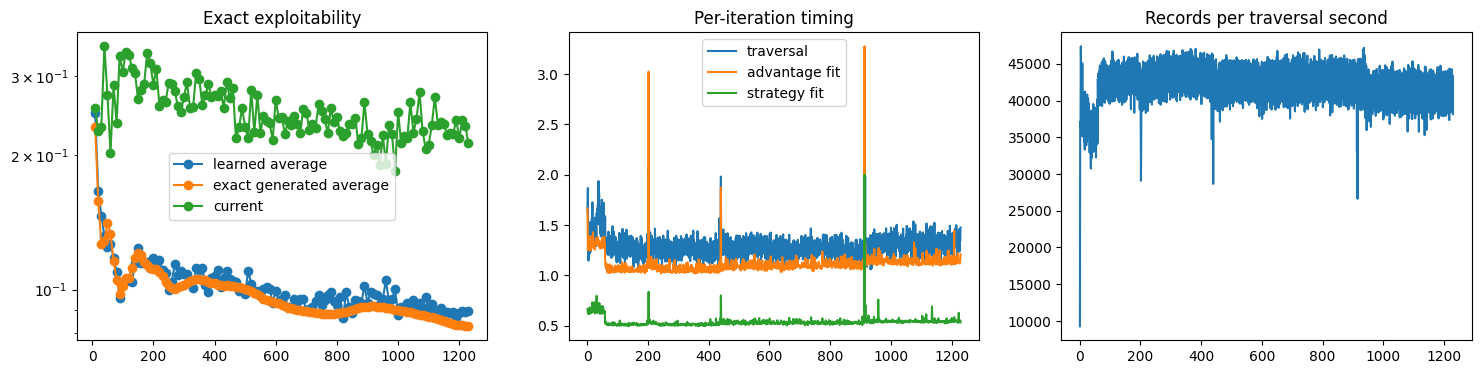

In [26]:
if logs['training_series']:
    train_df = pd.json_normalize(logs['training_series'])
    eval_df = pd.DataFrame(logs['exploitability_series'])
    for col in ['predicted_avg', 'exact_average_predicted_avg', 'current_predicted_avg']:
        if col in eval_df:
            eval_df[col.replace('predicted_avg', 'exploitability')] = (2 * eval_df[col] - 1).clip(lower=1e-8)
    display(train_df.tail())
    display(eval_df.tail())

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(eval_df['iter'], eval_df['exploitability'], marker='o', label='learned average')
    if 'exact_average_predicted_avg' in eval_df:
        axes[0].plot(eval_df['iter'], eval_df['exact_average_exploitability'], marker='o', label='exact generated average')
    axes[0].plot(eval_df['iter'], eval_df['current_exploitability'], marker='o', label='current')
    axes[0].set_yscale('log')
    axes[0].set_title('Exact exploitability')
    axes[0].legend()

    axes[1].plot(train_df['iteration'], train_df['timing.traversal_s'], label='traversal')
    axes[1].plot(train_df['iteration'], train_df['timing.advantage_training_s'], label='advantage fit')
    axes[1].plot(train_df['iteration'], train_df['timing.strategy_training_s'], label='strategy fit')
    axes[1].set_title('Per-iteration timing')
    axes[1].legend()

    records = train_df['new_advantage_records'].apply(sum) + train_df['new_strategy_records'].apply(sum)
    axes[2].plot(train_df['iteration'], records / train_df['timing.traversal_s'])
    axes[2].set_title('Records per traversal second')
    plt.show()

In [13]:
RUN_GPU_TRAINING = True

if RUN_GPU_TRAINING:
    run_spec = GameSpec(
        ranks=4,
        suits=4,
        hand_size=3,
        claim_kinds=('RankHigh', 'Pair', 'Trips'),
        suit_symmetry=True,
    )
    exact_averager = ExactDenseStrategyAverager(run_spec)
    trainer = DeepCFRTrainer(
        run_spec,
        hidden_sizes=(256, 256),
        device=device,
        seed=7,
        batch_size=1024 if torch.cuda.is_available() else 256,
        advantage_train_steps=100,
        strategy_train_steps=50,
        advantage_positive_weight=0.5,
        advantage_buffer_capacity=300_000,
        strategy_buffer_capacity=300_000,
        traversal_backend='recursive',
        traversal_batch_size=512 if torch.cuda.is_available() else 1,
        validation_fraction=0.02,
        validation_buffer_capacity=20_000,
    )
    policy, logs, trainer = deep_cfr_timed_loop(
        run_spec,
        training_seconds=30*60,
        trainer=trainer,
        traversals_per_player=512,
        eval_every=10,
        exact_averager=exact_averager,
        debug=True,
    )
else:
    logs = {'training_series': [], 'exploitability_series': []}
    trainer = None
    policy = None

[deep-cfr] iter=1 training_budget=7.11/1800.00s traverse=5.55s fit=1.56s
[deep-cfr] iter=2 training_budget=30.50/1800.00s traverse=21.84s fit=1.55s
[deep-cfr] iter=3 training_budget=45.72/1800.00s traverse=13.70s fit=1.52s
[deep-cfr] iter=4 training_budget=62.60/1800.00s traverse=15.36s fit=1.52s
[deep-cfr] iter=5 training_budget=81.31/1800.00s traverse=17.15s fit=1.56s
[deep-cfr] iter=6 training_budget=100.16/1800.00s traverse=17.30s fit=1.54s
[deep-cfr] iter=7 training_budget=119.24/1800.00s traverse=17.53s fit=1.55s
[deep-cfr] iter=8 training_budget=139.29/1800.00s traverse=18.52s fit=1.52s
[deep-cfr] iter=9 training_budget=168.22/1800.00s traverse=26.75s fit=2.18s
[deep-cfr] iter=10 training_budget=201.26/1800.00s traverse=31.10s fit=1.94s
[deep-cfr] iter=11 training_budget=230.83/1800.00s traverse=27.75s fit=1.83s
[deep-cfr] iter=12 training_budget=260.65/1800.00s traverse=28.01s fit=1.81s
[deep-cfr] iter=13 training_budget=290.94/1800.00s traverse=28.44s fit=1.85s
[deep-cfr] iter

,iteration,advantage_loss,strategy_loss,advantage_buffer_sizes,strategy_buffer_sizes,advantage_records_seen,strategy_records_seen,new_advantage_records,new_strategy_records,elapsed_s,timing.traversal_s,timing.advantage_training_s,timing.strategy_training_s,validation.advantage,validation.strategy
69,70,"[0.6454003036022187, 0.670591042637825]","[0.3605782639980316, 0.38348865568637847]","[300000, 192187]","[300000, 300000]","[667755, 192187]","[689438, 2222225]","[11919, 3139]","[10953, 34034]",1713.724288,26.489897,1.220180,0.566488,"[{'records': 2048, 'mse': 0.6450678110122681, ...","[{'records': 2048, 'cross_entropy': 0.51343381..."
70,71,"[0.6425924417376518, 0.6691521781682969]","[0.35631342262029647, 0.3973944222927093]","[300000, 195184]","[300000, 300000]","[678997, 195184]","[699274, 2255991]","[11242, 2997]","[9836, 33766]",1740.137077,24.582490,1.265175,0.565090,"[{'records': 2048, 'mse': 0.6551519632339478, ...","[{'records': 2048, 'cross_entropy': 0.50433158..."
71,72,"[0.636793566942215, 0.6697035068273545]","[0.3566198068857193, 0.3776016390323639]","[300000, 198552]","[300000, 300000]","[689559, 198552]","[710257, 2289279]","[10562, 3368]","[10983, 33288]",1766.500117,24.543818,1.255483,0.563694,"[{'records': 2048, 'mse': 0.6512038111686707, ...","[{'records': 2048, 'cross_entropy': 0.49533018..."
72,73,"[0.6503933000564576, 0.6716229432821273]","[0.3541307520866394, 0.3830205821990967]","[300000, 202096]","[300000, 300000]","[698795, 202096]","[722199, 2320374]","[9236, 3544]","[11942, 31095]",1791.697985,23.372596,1.246232,0.579003,"[{'records': 2048, 'mse': 0.6440603137016296, ...","[{'records': 2048, 'cross_entropy': 0.51481217..."
73,74,"[0.6449850291013718, 0.6569239228963852]","[0.35230382919311526, 0.38519624233245847]","[300000, 204973]","[300000, 300000]","[709140, 204973]","[731564, 2352487]","[10345, 2877]","[9365, 32113]",1817.336786,23.814141,1.232020,0.592603,"[{'records': 2048, 'mse': 0.6451597213745117, ...","[{'records': 2048, 'cross_entropy': 0.50581961..."


,iter,p_first,p_second,predicted_avg,current_p_first,current_p_second,current_predicted_avg,exact_average_p_first,exact_average_p_second,exact_average_predicted_avg,exploitability,exact_average_exploitability,current_exploitability
3,40,0.585180,0.556083,0.570632,0.642421,0.623815,0.633118,0.595147,0.548865,0.572006,0.141263,0.144012,0.266236
4,50,0.580753,0.551552,0.566152,0.648683,0.611334,0.630008,0.579700,0.549746,0.564723,0.132305,0.129446,0.260017
5,60,0.567133,0.545223,0.556178,0.660512,0.603134,0.631823,0.568380,0.542833,0.555606,0.112356,0.111213,0.263647
6,70,0.568064,0.545535,0.556800,0.672147,0.626754,0.649451,0.570463,0.539725,0.555094,0.113599,0.110188,0.298902
7,74,0.569340,0.541305,0.555323,0.727939,0.656866,0.692402,0.574119,0.539824,0.556971,0.110645,0.113943,0.384805


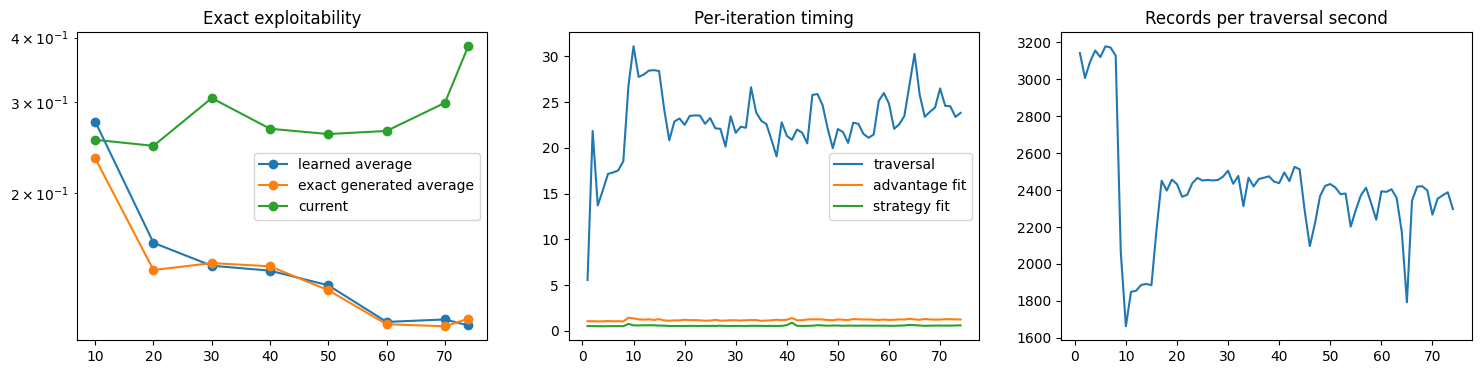

In [15]:
if logs['training_series']:
    train_df = pd.json_normalize(logs['training_series'])
    eval_df = pd.DataFrame(logs['exploitability_series'])
    for col in ['predicted_avg', 'exact_average_predicted_avg', 'current_predicted_avg']:
        if col in eval_df:
            eval_df[col.replace('predicted_avg', 'exploitability')] = (2 * eval_df[col] - 1).clip(lower=1e-8)
    display(train_df.tail())
    display(eval_df.tail())

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(eval_df['iter'], eval_df['exploitability'], marker='o', label='learned average')
    if 'exact_average_predicted_avg' in eval_df:
        axes[0].plot(eval_df['iter'], eval_df['exact_average_exploitability'], marker='o', label='exact generated average')
    axes[0].plot(eval_df['iter'], eval_df['current_exploitability'], marker='o', label='current')
    axes[0].set_yscale('log')
    axes[0].set_title('Exact exploitability')
    axes[0].legend()

    axes[1].plot(train_df['iteration'], train_df['timing.traversal_s'], label='traversal')
    axes[1].plot(train_df['iteration'], train_df['timing.advantage_training_s'], label='advantage fit')
    axes[1].plot(train_df['iteration'], train_df['timing.strategy_training_s'], label='strategy fit')
    axes[1].set_title('Per-iteration timing')
    axes[1].legend()

    records = train_df['new_advantage_records'].apply(sum) + train_df['new_strategy_records'].apply(sum)
    axes[2].plot(train_df['iteration'], records / train_df['timing.traversal_s'])
    axes[2].set_title('Records per traversal second')
    plt.show()